In [ ]:
# pip install --force-reinstall --upgrade git+https://github.com/SerjWeesp/AmarinML.git
from amarinml import *

00{"name":"Exception","message":"not_supported","stack":["Traceback \u001b(most recent call last)\u001b:\n","\u001b  \u001b\u001bFile \u001b\u001b<string>:174\u001b\u001b in \u001b\u001b__DW_DEBUG_WRAPPER__\u001b\n","\u001b  \u001b\u001bFile \u001b\u001b<string>:165\u001b\u001b in \u001b\u001b__DW_GET_EXPRESSION_VARIABLE__\u001b\n","\u001bException\u001b\u001b:\u001b not_supported\n"]}
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
00{"name":"Exception","message":"not_supported","stack":["Traceback \u001b(most recent call last)\u001b:\n","\u001b  \u001b\u001bFile \u001b\u001b<string>:174\u001b\u001b in \u001b\u001b__DW_DEBUG_WRAPPER__\u001b\n","\u001b  \u001b\u001bFil

In [8]:
import numpy as np
import pandas as pd
import copy
import os
import joblib
import ctypes
import gc
from probatus.feature_elimination import ShapRFECV
from skopt.space import Real, Integer
from skopt import BayesSearchCV
from catboost import CatBoostRegressor, Pool
from feature_engine.outliers import OutlierTrimmer
from feature_engine.encoding import RareLabelEncoder
from feature_engine.selection import DropConstantFeatures, DropCorrelatedFeatures, RecursiveFeatureElimination
import shap
from probatus.utils import Scorer
from sklearn.metrics import mean_squared_error, make_scorer, mean_pinball_loss, mean_absolute_error, classification_report, confusion_matrix, median_absolute_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score

os.environ.pop("OPENBLAS_NUM_THREADS", None)  # None = ignore if not present
SEED = 23
pd.set_option('display.max_columns', None)

In [9]:
# tell Windows to stay awake
ctypes.windll.kernel32.SetThreadExecutionState(0x80000000 | 0x00000001)

-2147483647

In [10]:
class SinglePointTimeSeriesSplitByTicker:
    """
    Forward-expanding, single-point test per split (per ticker).
    For each ticker with N rows and n_splits = k, the test positions are:
    N-k, N-k+1, ..., N-1  (0-based within that ticker).
    """

    def __init__(self, n_splits=3):
        if n_splits < 1:
            raise ValueError(f"n_splits must be >= 1, got {n_splits}")
        self.n_splits = n_splits

    def split(self, X, y=None, groups=None):
        if not isinstance(X, pd.DataFrame):
            raise ValueError(
                "X must be a pandas DataFrame with 'Ticker' column")
        if 'Ticker' not in X.columns:
            raise ValueError("DataFrame must have a 'Ticker' column")

        # IMPORTANT: X must be sorted by time within each ticker BEFORE calling split.

        # Precompute positional indices (0..len(X)-1) for each ticker
        tickers = X['Ticker'].to_numpy()
        unique_tickers = pd.unique(tickers)
        ticker_to_pos = {t: np.where(tickers == t)[0] for t in unique_tickers}

        for i in range(self.n_splits):
            train_idx, test_idx = [], []

            for t, pos in ticker_to_pos.items():
                n = len(pos)
                # Need at least n_splits + 1 rows for this ticker
                if n <= self.n_splits:
                    continue

                # forward-expanding single test index (position within this ticker)
                test_pos_in_ticker = n - self.n_splits + i  # e.g., for n=10,k=3: 7,8,9
                test_idx.append(pos[test_pos_in_ticker])
                train_idx.extend(pos[:test_pos_in_ticker])

            if test_idx:
                gc.collect()
                yield np.array(train_idx), np.array(test_idx)

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

In [11]:
# --- Two tickers with different lengths: A=8, B=12 ---
df = pd.DataFrame({
    "Ticker": ["A"]*8 + ["B"]*12,
    "t": list(range(8)) + list(range(12))
})

cv = SinglePointTimeSeriesSplitByTicker(n_splits=2)
for k, (tr, te) in enumerate(cv.split(df), 1):
    print(f"Fold {k}:")
    print("  train idx:", tr.tolist())
    print("  test idx :", te.tolist())

Fold 1:
  train idx: [0, 1, 2, 3, 4, 5, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
  test idx : [6, 18]
Fold 2:
  train idx: [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
  test idx : [7, 19]


In [12]:
df = pd.read_csv('D:\GitHub\sp500\data\sp500_diff_14052026.csv', low_memory=False)
df.drop(columns=['Unnamed: 0'], axis=1, inplace=True)
df.replace([np.inf, -np.inf], 0, inplace=True)
df.sort_values(by=['Ticker', 'Date'], inplace=True)
df.drop(['Quarter_pct_diff_1', 'Quarter_pct_diff_4',
        'Fiscal year_pct_diff_1', 'Fiscal year_pct_diff_4', 'Fiscal year'], axis=1, inplace=True)
df['Quarter'] = df['Quarter'].astype('int64').astype('category')
print(df.shape)

(17624, 1464)


In [13]:
target = 'Future_Price_pct_diff_1'
df[target] = df.groupby('Ticker')['ClosePrice_pct_diff_1'].shift(-1)

predict_df = pd.DataFrame()
for ticker in df['Ticker'].unique():
    ticker_df = df[df['Ticker'] == ticker]
    max_date = ticker_df['Date'].max()
    last_row = ticker_df.loc[ticker_df['Date'] == max_date, :].copy()
    predict_df = pd.concat([predict_df, last_row], ignore_index=True)

df.dropna(inplace=True)
features = df.drop(columns=[target,  'Date'], axis=1).columns.tolist()
cat_features = df.drop(columns=[target, 'Date'], axis=1).select_dtypes(
    include=['object', 'category']).columns.tolist()
num_features = df.drop(columns=[target], axis=1).select_dtypes(
    include=['int64', 'float64']).columns.tolist()
print(
    f'Length of numerical features: {len(num_features)}, categorical: {len(cat_features)} , all features: {len(features)}')

Length of numerical features: 1459, categorical: 4 , all features: 1463


In [14]:
train_df = df.copy()
X_train = train_df[features]
y_train = train_df[target]

In [15]:
# Store average CV scores
medae_scores = []

# Try different delta values for Huber robustness
for delta in [0.5, 1.0, 2.0, 3.0]:
    # Define CatBoost with Huber loss
    model = CatBoostRegressor(
        iterations=100,
        learning_rate=0.1,
        depth=6,
        random_seed=SEED,
        loss_function=f'Huber:delta={delta}',
        eval_metric='RMSE',
        verbose=False,
        thread_count=-1,
        devices='0',
        task_type="GPU",
        data_partition='DocParallel',
        max_ctr_complexity=1,
        cat_features=cat_features,
        boosting_type='Plain',
        bootstrap_type="Bernoulli",
        subsample=0.7,
        border_count=128,
        early_stopping_rounds=50,
        allow_writing_files=False,
        grow_policy="SymmetricTree",
        gpu_ram_part=0.95,
    )

    # Time-series cross-validation
    tscv = SinglePointTimeSeriesSplitByTicker(n_splits=4)

    # Define Median Absolute Error scorer
    medae_scorer = make_scorer(median_absolute_error, greater_is_better=False)

    # Cross-validation with MedAE
    scores = cross_val_score(model, X_train, y_train,
                             cv=tscv, scoring=medae_scorer)
    print(f"Delta={delta}, Scores={scores}")
    medae_scores.append(scores.mean())

print("Average Median Absolute Error scores by delta:", medae_scores)

Delta=0.5, Scores=[-0.08991283 -0.08700636 -0.10294608 -0.09793523]
Delta=1.0, Scores=[-0.08978545 -0.08613879 -0.10951897 -0.09556659]
Delta=2.0, Scores=[-0.08838856 -0.08741784 -0.11316036 -0.09477492]
Delta=3.0, Scores=[-0.08866844 -0.08554653 -0.10717798 -0.09317994]
Average Median Absolute Error scores by delta: [-0.0944501258189192, -0.09525244935087686, -0.09593542105379069, -0.09364322140011509]


In [16]:
model = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_seed=SEED,
    loss_function=f'Huber:delta=2.0',
    eval_metric='RMSE',
    verbose=False,
    thread_count=-1,
    devices='0',
    task_type="GPU",
    data_partition='DocParallel',
    max_ctr_complexity=1,
    cat_features=cat_features,
    boosting_type='Plain',
    bootstrap_type="Bernoulli",
    subsample=0.7,
    border_count=128,
    early_stopping_rounds=50,
    allow_writing_files=False,
    grow_policy="SymmetricTree",
    gpu_ram_part=0.9,
)

In [17]:
model.fit(X_train, y_train, cat_features=cat_features, verbose=False)

# Retrieve feature importances
importances = model.get_feature_importance()

# Retrieve the corresponding feature names (if available)
feature_names = model.feature_names_

# Create a DataFrame with the feature names and their importances
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort the DataFrame in descending order by importance
importance_df = importance_df.sort_values(by='importance', ascending=False)

# Print the top 30 important features
print(importance_df.head(30))

                                           feature  importance
370                                        Quarter   12.728368
620                          ClosePrice_pct_diff_4    4.446089
619                          ClosePrice_pct_diff_1    4.399875
954                           MinVolume_pct_diff_4    3.640249
951                            MinPrice_pct_diff_1    2.921163
1279                            Revenue_pct_diff_1    2.078141
222                          Market Capitalization    2.064912
220                                     Market Cap    1.954088
763                          Forward PE_pct_diff_1    1.931963
936                            MaxPrice_pct_diff_4    1.752066
930                          Market Cap_pct_diff_4    1.434752
125                               Enterprise Value    1.328094
762   Foreign Exchange Rate Adjustments_pct_diff_4    1.265866
1278  Return on Invested Capital (ROIC)_pct_diff_4    1.082203
929                          Market Cap_pct_diff_1    1

In [ ]:
# wrap the sklearn scorer in a probatus Scorer (ShapRFECV requires probatus.utils.Scorer)
probatus_medae = Scorer("medae", custom_scorer=medae_scorer)

shap_selector = ShapRFECV(
    model=model,
    cv=tscv,
    step=0.1,
    scoring=probatus_medae,
    n_jobs=1,
    verbose=1,
    random_state=SEED)

shap_selector.fit(X_train, y_train, columns_to_keep=cat_features)

c:\Users\Dell\miniforge3\envs\gpu311\Lib\site-packages\probatus\utils\arrayfuncs.py:108: UserWarning: The following variables in X contains categorical variables: ['Ticker', 'Quarter', 'GICS Sector', 'GICS Sub-Industry']. Make sure to use a model that handles them automatically or encode them into numerical variables.
  warnings.warn(
c:\Users\Dell\miniforge3\envs\gpu311\Lib\site-packages\probatus\utils\arrayfuncs.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[object_columns] = X[object_columns].astype("category")


Selected: 9 ['Ticker', 'Market Cap', 'Market Capitalization', 'Quarter', 'GICS Sector', 'GICS Sub-Industry', 'ClosePrice_pct_diff_1', 'Forward PE_pct_diff_1', 'Market Cap_pct_diff_4']


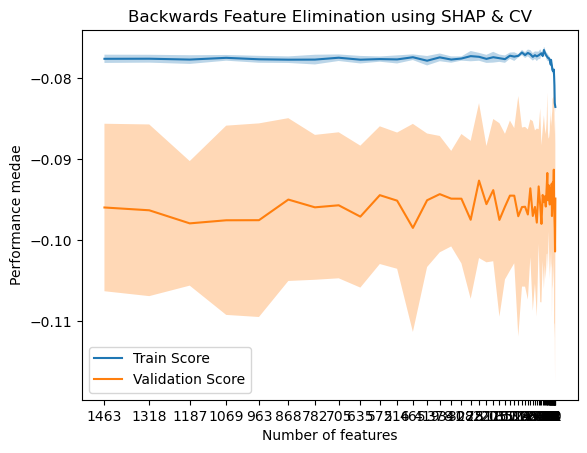

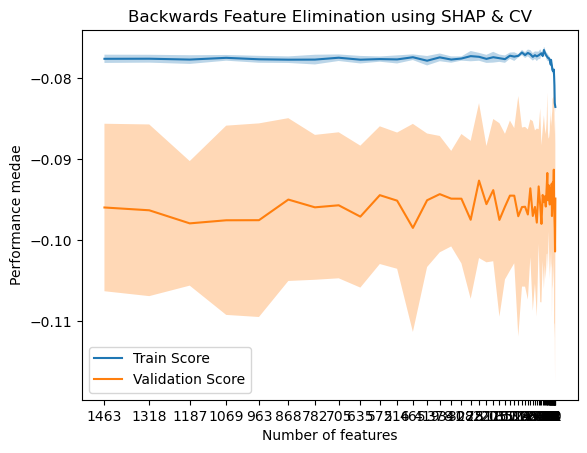

In [ ]:
selected = shap_selector..get_reduced_features_set(num_features=35)
print("Selected:", len(selected), selected)
shap_selector.plot()

In [20]:
n_iter = 30

# Define search space
param_space = {
    'learning_rate': Real(0.02, 0.2, prior='log-uniform'),
    'depth': Integer(4, 8),
    'l2_leaf_reg': Real(1e-3, 5.0, prior='log-uniform'),
    'iterations': Integer(500, 3000),
    'random_strength': Real(1e-3, 2.0, prior='log-uniform'),
    'min_data_in_leaf': Integer(10, 200),
    'leaf_estimation_iterations': Integer(1, 8),
    'subsample': Real(0.6, 0.9),
}


# Initialize the progress bar with the number of iterations
callback = TqdmCallback(total=n_iter)

opt = BayesSearchCV(
    estimator=model,
    search_spaces=param_space,
    n_iter=n_iter,
    cv=tscv,
    scoring=medae_scorer,
    n_jobs=1,
    n_points=1,
    random_state=SEED,
)

# Fit gs
opt.fit(X_train[selected], y_train, cat_features=cat_features,
        callback=callback, verbose=False)

# Retrieve the best model and results
best_model = opt.best_estimator_
results = opt.cv_results_
params = results['params']

# Best model and parameters
print("Best score:", opt.best_score_)
print("Best params:", opt.best_params_)

joblib.dump(best_model, 'sp500_best_catboost_model.pkl')

100%|██████████| 30/30 [39:17<00:00, 72.57s/it] 

Best score: -0.09017912471179591
Best params: OrderedDict([('depth', 4), ('iterations', 501), ('l2_leaf_reg', 1.8383302510279216), ('leaf_estimation_iterations', 2), ('learning_rate', 0.05443083262336441), ('min_data_in_leaf', 173), ('random_strength', 0.001198788053973668), ('subsample', 0.6410549753212804)])


['sp500_best_catboost_model.pkl']

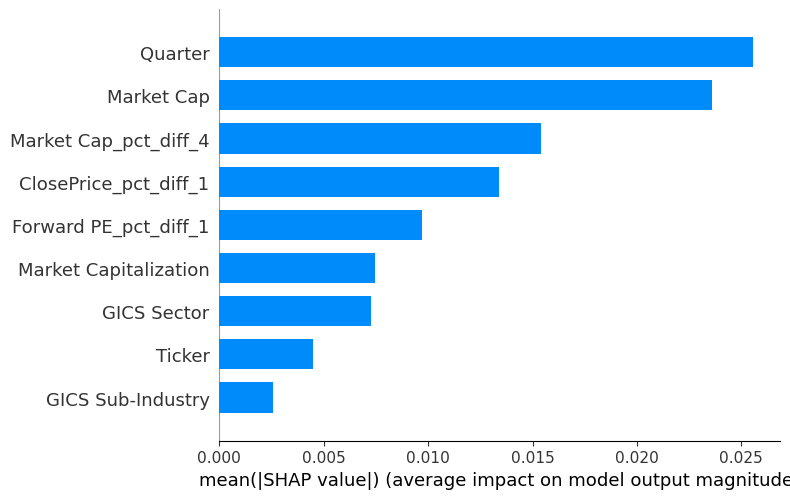

In [21]:
# Use the best model and the selected features
explainer = shap.Explainer(best_model)
shap_values = explainer(X_train[selected])


shap.summary_plot(shap_values, X_train[selected], plot_type="bar")

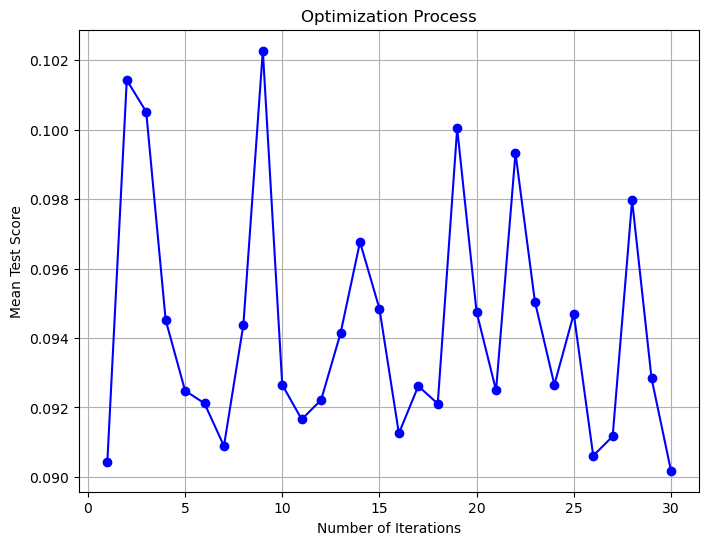

In [22]:
# Extract the results
results = pd.DataFrame(opt.cv_results_)
results['mean_test_score'] = -results['mean_test_score']

# Extract the mean test scores and number of iterations
iterations = np.arange(1, n_iter + 1)

# Plot the scores
plt.figure(figsize=(8, 6))
plt.plot(iterations, results['mean_test_score'],
         marker='o', linestyle='-', color='b')
plt.xlabel('Number of Iterations')
plt.ylabel('Mean Test Score')
plt.title('Optimization Process')
plt.grid(True)
plt.show()

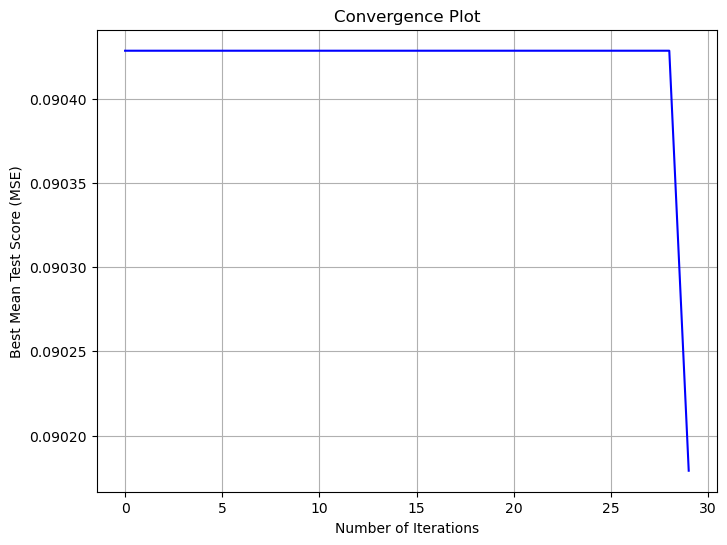

In [23]:
# Extract best scores at each iteration
best_scores = np.minimum.accumulate(results['mean_test_score'])

# Plot the convergence
plt.figure(figsize=(8, 6))
plt.plot(best_scores, linestyle='-', color='b')
plt.xlabel('Number of Iterations')
plt.ylabel('Best Mean Test Score (MSE)')
plt.title('Convergence Plot')
plt.grid(True)
plt.show()

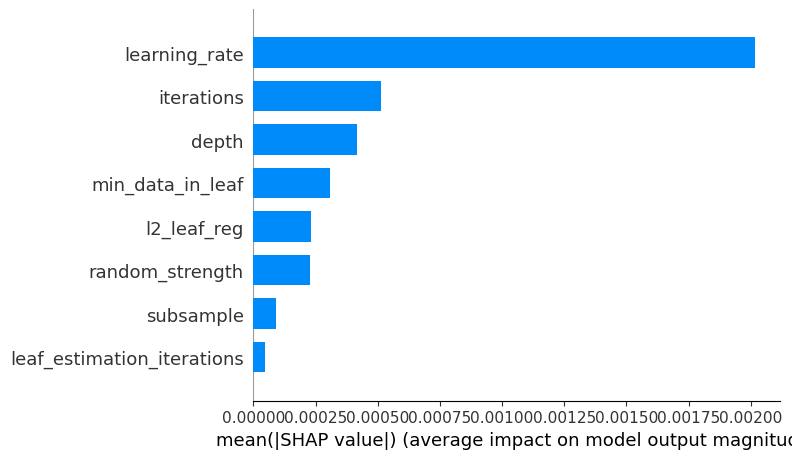

In [24]:

# Mean test scores are negative due to the scoring used
mean_test_scores = -results['mean_test_score']

# Create a DataFrame for analysis
hyperparams_df = pd.DataFrame(params)
hyperparams_df['mean_test_score'] = mean_test_scores

# If any hyperparameters are strings (e.g. loss_function), encode them
for col in hyperparams_df.drop('mean_test_score', axis=1).select_dtypes(include='object').columns:
    hyperparams_df[col] = hyperparams_df[col].astype('category').cat.codes

# Rebuild a fresh CatBoostRegressor with the best hyperparameters from search
best_params = opt.best_params_

# Fit a simple model to explain the hyperparameter importance
hyperparam_model = CatBoostRegressor(**best_params, verbose=0)

hyperparam_model.fit(
    hyperparams_df.drop('mean_test_score', axis=1),
    hyperparams_df['mean_test_score']
)

hyperparam_model.fit(hyperparams_df.drop(
    'mean_test_score', axis=1), hyperparams_df['mean_test_score'])


# Create a SHAP explainer
explainer = shap.Explainer(hyperparam_model)
shap_values = explainer(hyperparams_df.drop('mean_test_score', axis=1))

# Plot feature importance based on SHAP values
shap.summary_plot(shap_values, hyperparams_df.drop(
    'mean_test_score', axis=1), plot_type="bar")

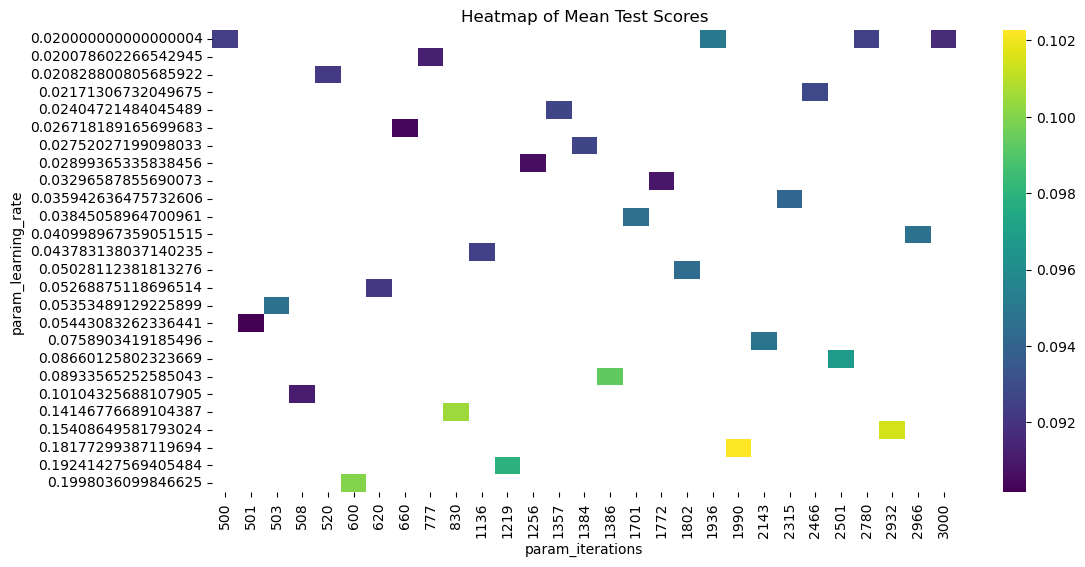

In [25]:
# Create a pivot table for the heatmap
pivot_table = pd.DataFrame(results).pivot_table(
    values='mean_test_score',
    index='param_learning_rate',
    columns='param_iterations',
    aggfunc='mean'
)

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=False, fmt=".1f", cmap="viridis")
plt.title('Heatmap of Mean Test Scores')
plt.show()

In [26]:
best_model = joblib.load('sp500_best_catboost_model.pkl')

In [27]:
# Get the train/test indices for the last fold
splits = list(tscv.split(X_train, y_train))
train_idx, test_idx = splits[-1]   # last element

# Slice data
X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
X_te, y_te = X_train.iloc[test_idx], y_train.iloc[test_idx]

best_model.fit(X_tr[selected], y_tr)

# Predictions on the last fold test set
y_pred = model.predict(X_te)

preds_binary = [1 if i > 0 else 0 for i in y_pred]
test_binary = [1 if i > 0 else 0 for i in y_te]

print(confusion_matrix(test_binary, preds_binary))
print(classification_report(test_binary, preds_binary))

[[105 142]
 [ 40 188]]
              precision    recall  f1-score   support

           0       0.72      0.43      0.54       247
           1       0.57      0.82      0.67       228

    accuracy                           0.62       475
   macro avg       0.65      0.62      0.60       475
weighted avg       0.65      0.62      0.60       475



In [28]:
# Create a DataFrame to store actual, predicted, and errors
errors = np.abs(y_te - y_pred)
error_df = X_te[['Ticker']].copy()
error_df['Observed'] = y_te
error_df['Predicted'] = y_pred
error_df['Absolute Error'] = errors

# Sort by error in descending order and display the top 30
top_30_errors = error_df.sort_values(
    by='Absolute Error', ascending=False).head(30)

print('Median absolute error:', np.median(errors))
top_30_errors

Median absolute error: 0.08226592221939066


,Ticker,Observed,Predicted,Absolute Error
999,AMD,1.583313,0.853436,0.729877
744,AKAM,0.568546,0.019107,0.549439
12266,ON,0.567435,0.019390,0.548045
8474,INTC,0.831373,0.329906,0.501467
1230,ANET,0.605321,0.154403,0.450918
4487,DDOG,0.549762,0.101796,0.447966
6829,FTNT,0.474725,0.035813,0.438912
9223,KEYS,0.433083,-0.002509,0.435592
8512,INTU,-0.380104,0.021762,0.401867
6551,FICO,-0.337668,0.047273,0.384941


In [29]:
# Sort by error in descending order and display the top 30
top_30_errors = error_df.sort_values(
    by='Predicted', ascending=False).head(30)

top_30_errors

,Ticker,Observed,Predicted,Absolute Error
999,AMD,1.583313,0.853436,0.729877
11334,MU,0.788169,0.407531,0.380638
16887,WDC,0.725319,0.352275,0.373043
8474,INTC,0.831373,0.329906,0.501467
14693,STX,0.580667,0.285830,0.294837
1230,ANET,0.605321,0.154403,0.450918
3692,COIN,0.367638,0.139648,0.227990
4596,DELL,0.137497,0.136518,0.000979
783,ALB,0.100651,0.130525,0.029874
4884,DOC,0.087937,0.120575,0.032638


In [30]:
preds = best_model.predict(predict_df[selected])
predict_next = pd.DataFrame([predict_df['Ticker'].unique(), preds*100]).T.rename(
    columns={0: 'Ticker', 1: 'Predicted price change pct'}).sort_values(by='Predicted price change pct',
                                                                        ascending=False)
predict_next.head(10)

,Ticker,Predicted price change pct
181,FISV,45.240445
41,ARE,43.204795
53,BAX,30.118832
19,AKAM,29.274282
215,HOOD,25.526876
425,TTD,24.258054
407,TECH,23.632374
156,EPAM,23.506297
455,WDC,22.762985
296,MOS,20.199442


In [31]:
predict_next.tail(10).sort_values(by='Predicted price change pct',
                                  ascending=True)

,Ticker,Predicted price change pct
233,INTU,-10.0188
179,FICO,-7.335105
109,CRM,-6.422312
454,WDAY,-4.367781
175,FDS,-3.891654
191,GDDY,-3.842091
323,NVDA,-3.829697
337,PANW,-3.728684
284,MCK,-3.691029
127,DELL,-3.382541


In [32]:
fin_features = ['Revenue', 'Net Income', 'EBIT Margin', 'Free Cash Flow Margin', 'Dividend Growth', \
                'Revenue_pct_diff_1', 'Net Income_pct_diff_1', 'EBIT Margin_pct_diff_1', 'Free Cash Flow Margin_pct_diff_1', 'Dividend Growth_pct_diff_1', \
                'Revenue_pct_diff_4', 'Net Income_pct_diff_4', 'EBIT Margin_pct_diff_4', 'Free Cash Flow Margin_pct_diff_4', 'Dividend Growth_pct_diff_4']
df.loc[df['Ticker']=='NVDA', fin_features].iloc[-4:]

,Revenue,Net Income,EBIT Margin,Free Cash Flow Margin,Dividend Growth,Revenue_pct_diff_1,Net Income_pct_diff_1,EBIT Margin_pct_diff_1,Free Cash Flow Margin_pct_diff_1,Dividend Growth_pct_diff_1,Revenue_pct_diff_4,Net Income_pct_diff_4,EBIT Margin_pct_diff_4,Free Cash Flow Margin_pct_diff_4,Dividend Growth_pct_diff_4
11951,39331.0,22091.0,0.6111,0.3954,1.5,0.121116,0.144078,-0.019731,-0.175047,0.0,0.779442,0.798209,-0.007793,-0.222877,0.0
11952,44062.0,18775.0,0.4911,0.5943,1.5,0.120287,-0.150106,-0.196367,0.503035,0.0,0.691829,0.261676,-0.243530,0.033565,0.0
11953,46743.0,26422.0,0.6084,0.2882,0.0,0.060846,0.407297,0.238852,-0.515060,-1.0,0.556025,0.591783,-0.019658,-0.359271,-1.0
11954,57006.0,31910.0,0.6317,0.0000,0.0,0.219562,0.207706,0.038297,-1.000000,0.0,0.624936,0.652597,0.013314,-1.000000,-1.0


In [33]:
def gains_test(df, model, tscv, top_n=3):
    cv = tscv
    splits = list(cv.split(df))
    gains_df = pd.DataFrame()
    for i in range(-8, -4):
        train_idx, test_idx = splits[i]

        X_tr = df.iloc[train_idx][features]
        y_tr = df.iloc[train_idx][target]
        X_te = df.iloc[test_idx]
        model.fit(X_tr, y_tr, cat_features=cat_features, verbose=False)
        preds = model.predict(X_te[features])

        pred_df = pd.DataFrame({
            'Ticker': df.iloc[test_idx]['Ticker'].values,
            'Predicted price change pct': preds 
        }).sort_values(by='Predicted price change pct', ascending=False)

        to_buy = pred_df['Ticker'].head(top_n)
        
        for t in to_buy:
            buy_1q = X_te[X_te['Ticker'] == t][['Ticker', 'Date', target]].copy()
            buy_1q['Period'] = i
            buy_1q['Future_Price_pct_diff_4'] = df.loc[df['Ticker']==t, "ClosePrice_pct_diff_4"].iloc[i+4]
            gains_df = pd.concat([gains_df, buy_1q], ignore_index=True)
    
    return gains_df

In [34]:
cv = SinglePointTimeSeriesSplitByTicker(n_splits=8)
gains_df = gains_test(df, model, cv, top_n=5)
gains_df

,Ticker,Date,Future_Price_pct_diff_1,Period,Future_Price_pct_diff_4
0,EME,2024-04-25,-0.007212,-8,0.149708
1,NCLH,2024-05-07,-0.005128,-8,0.113462
2,STX,2024-04-26,0.106447,-8,0.113411
3,PYPL,2024-04-30,-0.057715,-8,-0.023557
4,CVNA,2024-05-01,0.529797,-8,1.975887
5,PANW,2024-05-21,0.077520,-7,0.163191
6,NVDA,2024-05-29,0.094015,-7,0.174433
7,JBL,2024-07-09,0.135231,-7,0.987204
8,FIX,2024-07-25,0.416670,-7,0.934197
9,LULU,2024-06-05,-0.159795,-7,0.073020


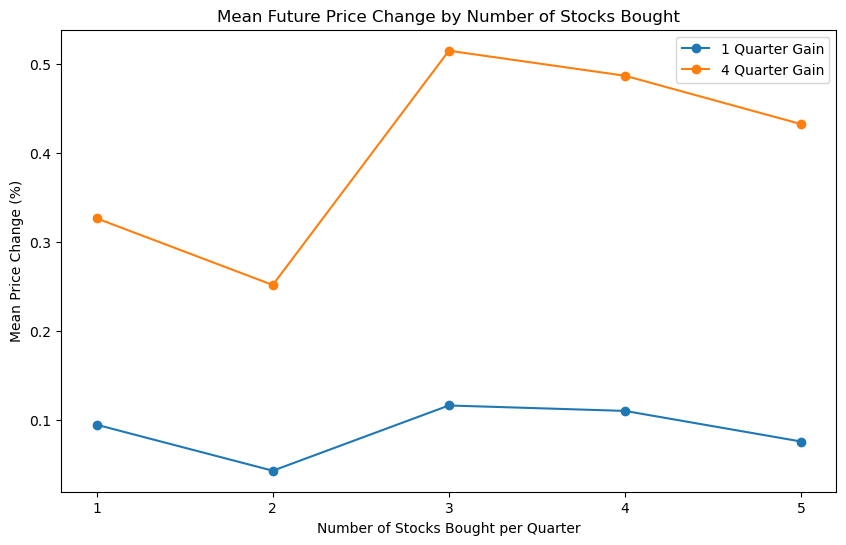

In [35]:
gains_1q = []
gains_4q = []
for n in range(1,6):
    gains_df = gains_test(df, model, cv, top_n=n)
    gains_1q.append(gains_df['Future_Price_pct_diff_1'].mean())
    gains_4q.append(gains_df['Future_Price_pct_diff_4'].mean())

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1,6), gains_1q, marker='o', label='1 Quarter Gain')
ax.plot(range(1,6), gains_4q, marker='o', label='4 Quarter Gain')
ax.set_xlabel('Number of Stocks Bought per Quarter')
ax.set_ylabel('Mean Price Change (%)')
ax.legend()
ax.set_xticks(range(1,6))
plt.title('Mean Future Price Change by Number of Stocks Bought')
plt.show()  

In [36]:
# restore normal sleep behavior
ctypes.windll.kernel32.SetThreadExecutionState(0x80000000)

-2147483647

In [37]:
import subprocess
subprocess.run(["powercfg", "-change", "-standby-timeout-ac", "30"], check=True)

CompletedProcess(args=['powercfg', '-change', '-standby-timeout-ac', '30'], returncode=0)